In [6]:
# # Linear vs. Non-Linear ML Models — Equity Return Prediction
# ### A rigorous, statistically sound comparison on SPY daily log returns
# ---
# **Structure:** 15 notebook blocks, each self-contained and explained.
# Run them top-to-bottom. Every block explains *why* the code exists,
# not just what it does.
 
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 1 — Installs & Imports
# ─────────────────────────────────────────────────────────────────────────────
# Run this pip line once if any library is missing.
# All packages listed are compatible with Python 3.14.x as of 2025/2026.
# ─────────────────────────────────────────────────────────────────────────────
 
# !pip install yfinance pandas numpy matplotlib seaborn scikit-learn scipy statsmodels
 
import sys
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
 
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import adfuller
 
# ── Linear ML models ──────────────────────────────────────────────────────────
# These fit a weighted sum of features: y_hat = w0 + w1*x1 + w2*x2 + ...
# They assume the relationship between inputs and output is additive and linear.
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
 
# ── Non-linear ML models ──────────────────────────────────────────────────────
# These can approximate arbitrary functions: interactions, thresholds, curvature.
# No linearity assumption is imposed.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
 
# ── Utilities ─────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
 
warnings.filterwarnings('ignore')
 
# ── Global plot style — applied once, inherited by all figures ─────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       110,
    'font.size':        10,
})
 
# ── Consistent color palette — Blue family = linear, Red/Orange = non-linear ──
# Keeping colors consistent across every chart makes comparisons immediate.
PALETTE = {
    'OLS':              '#1565C0',   # Dark blue
    'Ridge':            '#1E88E5',   # Medium blue
    'Lasso':            '#42A5F5',   # Light blue
    'ElasticNet':       '#00ACC1',   # Cyan
    'RandomForest':     '#C62828',   # Dark red
    'GradientBoosting': '#EF6C00',   # Deep orange
    'SVR':              '#F9A825',   # Amber
    'BuyAndHold':       '#2E7D32',   # Dark green (benchmark)
}
 
LINEAR_MODELS    = ['OLS', 'Ridge', 'Lasso', 'ElasticNet']
NONLINEAR_MODELS = ['RandomForest', 'GradientBoosting', 'SVR']
 
print(f"✅  Python {sys.version.split()[0]} | All libraries loaded successfully.")
 

✅  Python 3.14.3 | All libraries loaded successfully.


In [7]:
# ─────────────────────────────────────────────────────────────────────────
# BLOCK 2 — Data Download via yfinance
# ─────────────────────────────────────────────────────────────────────────────
# We use SPY (SPDR S&P 500 ETF) — one of the most liquid instruments globally.
# 10 years of daily data gives ~2,500 observations: enough for ML but not so
# long that structural breaks (e.g. 2008 GFC regime) dominate.
#
# auto_adjust=True applies stock split and dividend adjustments automatically,
# so price continuity is preserved. This matters for feature engineering.
# ─────────────────────────────────────────────────────────────────────────────
 
TICKER = 'SPY'
START  = '2015-01-01'
END    = '2024-12-31'
 
print(f"Downloading {TICKER}  [{START} → {END}]...")
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
 
# yfinance v0.2+ returns a MultiIndex when downloading.
# We flatten it to simple column names ('Close', 'Open', etc.).
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
 
raw = raw.dropna()
 
print(f"✅  {len(raw):,} trading days  ({raw.index[0].date()} → {raw.index[-1].date()})")
print(f"    Columns: {list(raw.columns)}")
raw.tail(3)
 

✅  2,515 trading days  (2015-01-02 → 2024-12-30)
    Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-26,592.741577,593.865231,589.528182,590.927860,41219100
2024-12-27,586.502075,589.232487,582.312845,588.995868,64969300
2024-12-30,579.809082,583.278769,576.053563,579.483844,56578800



  ┌── ADF Test: SPY Close Price
  │   Test Statistic :     0.7589
  │   p-value        :   0.990944
  │   5% Crit. Value :    -2.8627
  └── ❌ NON-STATIONARY  (fail to reject H₀)

  ┌── ADF Test: SPY Log Return
  │   Test Statistic :   -15.7265
  │   p-value        :   0.000000
  │   5% Crit. Value :    -2.8627
  └── ✅ STATIONARY  (reject H₀)


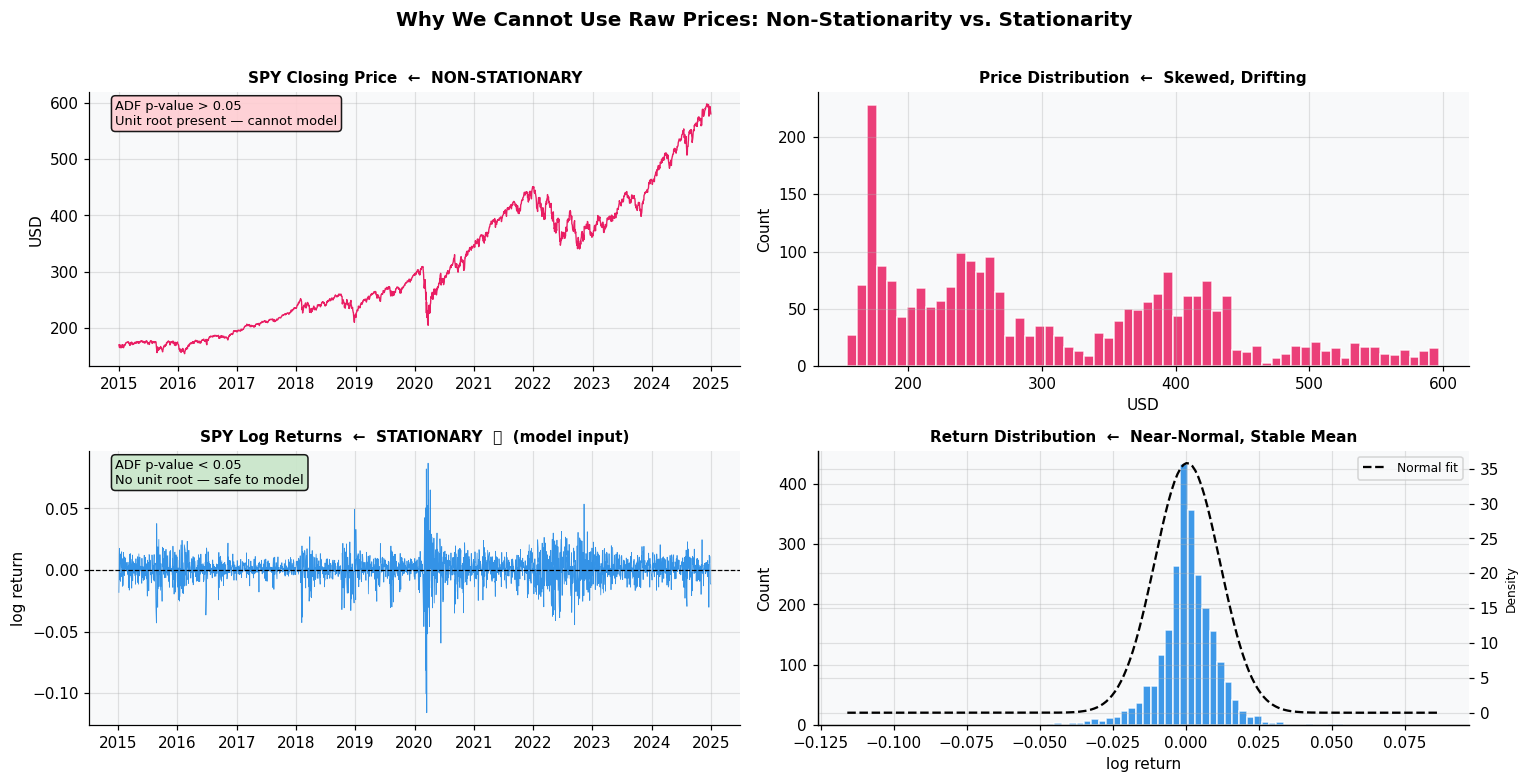

Figure saved → 01_stationarity.png


In [8]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 3 — Stationarity Check (ADF Test + Visual)
# ─────────────────────────────────────────────────────────────────────────────
# This is the most important theoretical block in the notebook.
#
# Raw stock prices follow a random walk: P_t = P_{t-1} + ε_t
# This makes them I(1) — "integrated of order 1" — meaning their
# statistical properties (mean, variance) drift over time.
#
# If we feed raw prices to a model, the model will pick up trends and
# levels that are artifacts of the non-stationarity, not real signal.
# It will appear to work in-sample, then collapse out-of-sample.
#
# The fix: use LOG RETURNS r_t = ln(P_t / P_{t-1}).
# Log returns are I(0) — stationary, with a stable mean near zero.
#
# We verify this formally with the Augmented Dickey-Fuller (ADF) test:
#   H₀: series has a unit root (non-stationary)
#   We reject H₀ at the 5% level if p-value < 0.05.
# ─────────────────────────────────────────────────────────────────────────────
 
prices  = raw['Close'].squeeze()
log_ret = np.log(prices / prices.shift(1)).dropna()
 
def adf_report(series: pd.Series, name: str) -> None:
    """Print a readable ADF test result."""
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    crit_5pct  = result[4]['5%']
    verdict    = "✅ STATIONARY  (reject H₀)" if pval < 0.05 else "❌ NON-STATIONARY  (fail to reject H₀)"
    print(f"\n  ┌── ADF Test: {name}")
    print(f"  │   Test Statistic : {stat:>10.4f}")
    print(f"  │   p-value        : {pval:>10.6f}")
    print(f"  │   5% Crit. Value : {crit_5pct:>10.4f}")
    print(f"  └── {verdict}")
 
adf_report(prices,  f'{TICKER} Close Price')
adf_report(log_ret, f'{TICKER} Log Return')
 
# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(
    'Why We Cannot Use Raw Prices: Non-Stationarity vs. Stationarity',
    fontsize=13, fontweight='bold', y=1.01
)
 
# Top row: Price level
ax = axes[0, 0]
ax.plot(prices.index, prices.values, color='#E91E63', lw=0.9)
ax.set_title('SPY Closing Price  ←  NON-STATIONARY', fontsize=10, fontweight='bold')
ax.set_ylabel('USD')
ax.text(0.04, 0.88,
        'ADF p-value > 0.05\nUnit root present — cannot model',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.9))
 
ax = axes[0, 1]
ax.hist(prices.values, bins=60, color='#E91E63', edgecolor='white', alpha=0.85)
ax.set_title('Price Distribution  ←  Skewed, Drifting', fontsize=10, fontweight='bold')
ax.set_xlabel('USD')
ax.set_ylabel('Count')
 
# Bottom row: Log returns
ax = axes[1, 0]
ax.plot(log_ret.index, log_ret.values, color='#1E88E5', lw=0.5, alpha=0.9)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('SPY Log Returns  ←  STATIONARY  ✅  (model input)', fontsize=10, fontweight='bold')
ax.set_ylabel('log return')
ax.text(0.04, 0.88,
        'ADF p-value < 0.05\nNo unit root — safe to model',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.9))
 
ax = axes[1, 1]
ax.hist(log_ret.values, bins=80, color='#1E88E5', edgecolor='white', alpha=0.85)
ax.set_title('Return Distribution  ←  Near-Normal, Stable Mean', fontsize=10, fontweight='bold')
ax.set_xlabel('log return')
ax.set_ylabel('Count')
# Overlay a normal distribution for comparison
mu, sigma = log_ret.mean(), log_ret.std()
xr = np.linspace(log_ret.min(), log_ret.max(), 200)
ax2_twin = ax.twinx()
ax2_twin.plot(xr, (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((xr-mu)/sigma)**2),
              color='black', lw=1.5, linestyle='--', label='Normal fit')
ax2_twin.set_ylabel('Density', fontsize=8)
ax2_twin.legend(fontsize=8)
ax2_twin.spines['top'].set_visible(False)
 
plt.tight_layout()
plt.savefig('01_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 01_stationarity.png")
 

Feature matrix: 2,493 rows × 16 features

Feature list:
  • ret_lag1
  • ret_lag2
  • ret_lag3
  • ret_lag4
  • ret_lag5
  • vol_5d
  • vol_21d
  • rsi_14
  • bollinger_b
  • volume_zscore
  • mom_5d
  • mom_21d
  • dow_1
  • dow_2
  • dow_3
  • dow_4


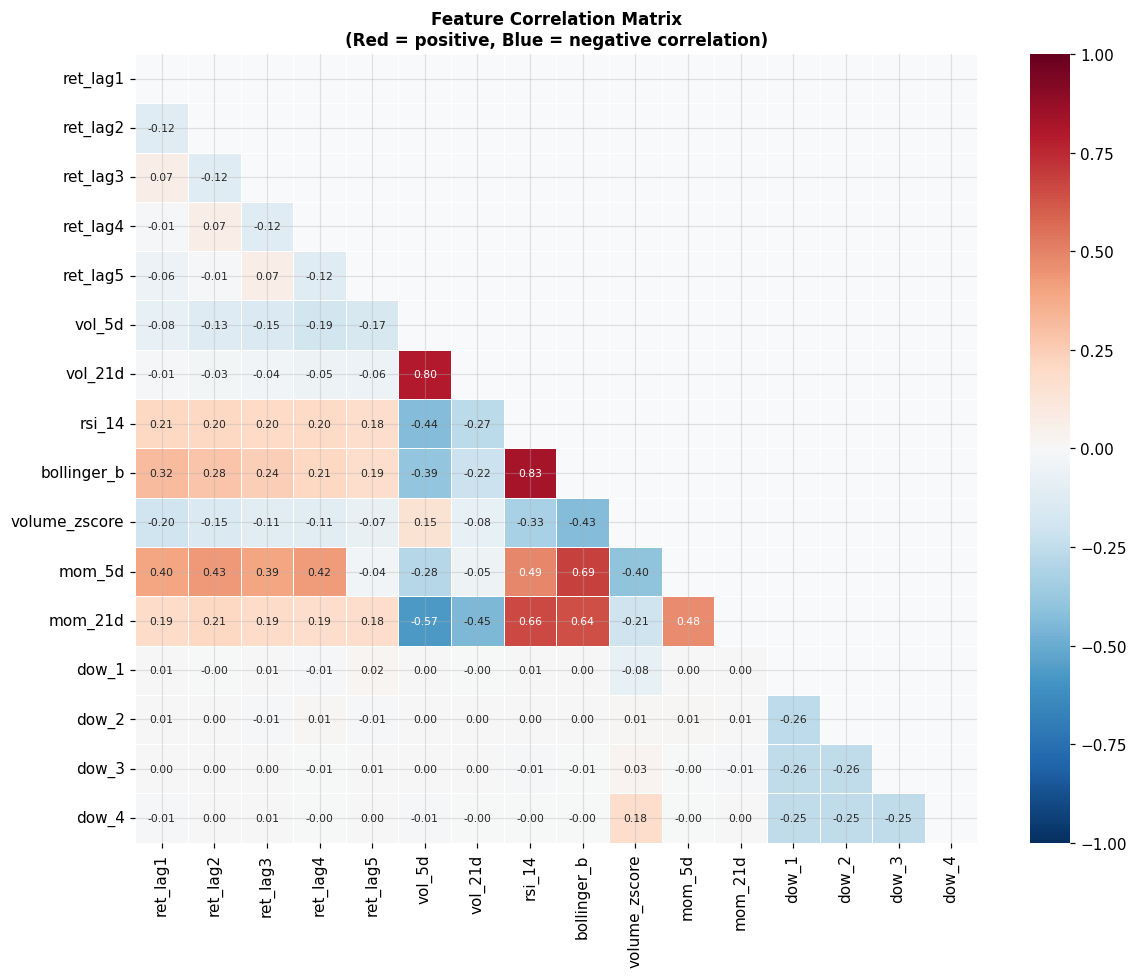

Figure saved → 02_feature_correlation.png


In [9]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 4 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
# We predict the NEXT day's log return (r_{t+1}) using features
# computed from information available at close of day t.
#
# LOOK-AHEAD RULE:
#   At close of day t, we observe P_t and r_t = ln(P_t/P_{t-1}).
#   Every feature must use only data ≤ t.
#   The target is r_{t+1}, implemented as:  target = r.shift(-1)
#   (shifting the return series back by 1 row aligns it with the features).
#
# Features chosen:
#   Lag returns (1–5d)      — autoregressive memory of the return series
#   Realized vol (5d, 21d)  — volatility regime; markets are vol-clustered
#   RSI (14d)               — mean-reversion / momentum indicator
#   Bollinger %B (20d)      — price position within its recent band
#   Volume z-score (21d)    — unusual volume precedes/accompanies moves
#   Momentum (5d, 21d)      — cumulative trend in recent windows
#   Day-of-week dummies     — Mon/Fri effects (well-documented in literature)
# ─────────────────────────────────────────────────────────────────────────────
 
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a feature matrix from OHLCV data.
    Every feature is backward-looking: it uses only data up to and
    including the current row. The target is the NEXT row's log return.
    """
    close  = df['Close'].squeeze()
    volume = df['Volume'].squeeze()
 
    # Daily log returns: r_t = ln(P_t / P_{t-1})
    r = np.log(close / close.shift(1))
 
    feat = pd.DataFrame(index=df.index)
 
    # ── Lagged returns ────────────────────────────────────────────────────────
    # lag1 = r_{t-1}, lag2 = r_{t-2}, ..., lag5 = r_{t-5}.
    # These are fully observable at close of day t — zero look-ahead.
    for lag in range(1, 6):
        feat[f'ret_lag{lag}'] = r.shift(lag)
 
    # ── Realized volatility ───────────────────────────────────────────────────
    # Rolling standard deviation of past returns.
    # vol_5d uses r[t-4:t], vol_21d uses r[t-20:t].
    # Both are available at close of t. Captures volatility clustering (GARCH effect).
    feat['vol_5d']  = r.rolling(5).std()
    feat['vol_21d'] = r.rolling(21).std()
 
    # ── RSI — Relative Strength Index (14-day) ────────────────────────────────
    # RSI measures the speed of recent price changes.
    # Values > 70 = overbought (potential reversal), < 30 = oversold.
    # Formula: RSI = 100 − 100/(1 + RS), where RS = avg_gain / avg_loss
    delta     = close.diff()
    gain      = delta.clip(lower=0).rolling(14).mean()
    loss      = (-delta.clip(upper=0)).rolling(14).mean()
    feat['rsi_14'] = 100 - 100 / (1 + gain / (loss + 1e-9))
 
    # ── Bollinger Band %B (20-day) ────────────────────────────────────────────
    # %B = (Price − Lower Band) / (Upper Band − Lower Band)
    # where bands are SMA ± 2σ.
    # %B ≈ 0 → at lower band (cheap); %B ≈ 1 → at upper band (expensive).
    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    feat['bollinger_b'] = (close - (sma20 - 2*std20)) / (4*std20 + 1e-9)
 
    # ── Volume z-score (21-day) ───────────────────────────────────────────────
    # How many standard deviations above its recent average is today's volume?
    # Volume spikes often coincide with institutional activity or news.
    vol_mu  = volume.rolling(21).mean()
    vol_std = volume.rolling(21).std()
    feat['volume_zscore'] = (volume - vol_mu) / (vol_std + 1e-9)
 
    # ── Momentum: cumulative return over rolling windows ──────────────────────
    # 5d momentum = log(P_t / P_{t-5}).  Captures short- and medium-term trend.
    feat['mom_5d']  = r.rolling(5).sum()
    feat['mom_21d'] = r.rolling(21).sum()
 
    # ── Day-of-week dummies ───────────────────────────────────────────────────
    # Monday = 0, Friday = 4. One-hot, drop_first to avoid dummy trap.
    # "Monday Effect" and "Friday Effect" are empirically documented in equity markets.
    dow = pd.get_dummies(
        pd.Series(df.index.dayofweek, index=df.index, name='dow'),
        prefix='dow', drop_first=True
    ).astype(float)
    feat = pd.concat([feat, dow], axis=1)
 
    # ── TARGET: next-day log return ───────────────────────────────────────────
    # shift(-1) means: at row t, the target is the return at t+1.
    # This is the ONLY thing that looks "forward" — and it is the thing
    # we want to predict, not a contaminating feature.
    feat['target'] = r.shift(-1)
 
    # Drop any rows with NaN (startup period for rolling windows, last row for target)
    return feat.dropna()
 
 
features_df  = compute_features(raw)
feature_cols = [c for c in features_df.columns if c != 'target']
 
print(f"Feature matrix: {features_df.shape[0]:,} rows × {len(feature_cols)} features")
print(f"\nFeature list:")
for f in feature_cols:
    print(f"  • {f}")
 
# ── Feature correlation heatmap ───────────────────────────────────────────────
# Multicollinearity (features that are highly correlated) can destabilize
# linear model coefficients. Tree models are immune but it's good to know.
fig, ax = plt.subplots(figsize=(11, 9))
corr = features_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Feature Correlation Matrix\n'
             '(Red = positive, Blue = negative correlation)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 02_feature_correlation.png")

TRAIN  1,993 days  (2015-02-03 → 2022-12-30)
TEST   500 days  (2023-01-03 → 2024-12-27)
Features: 16


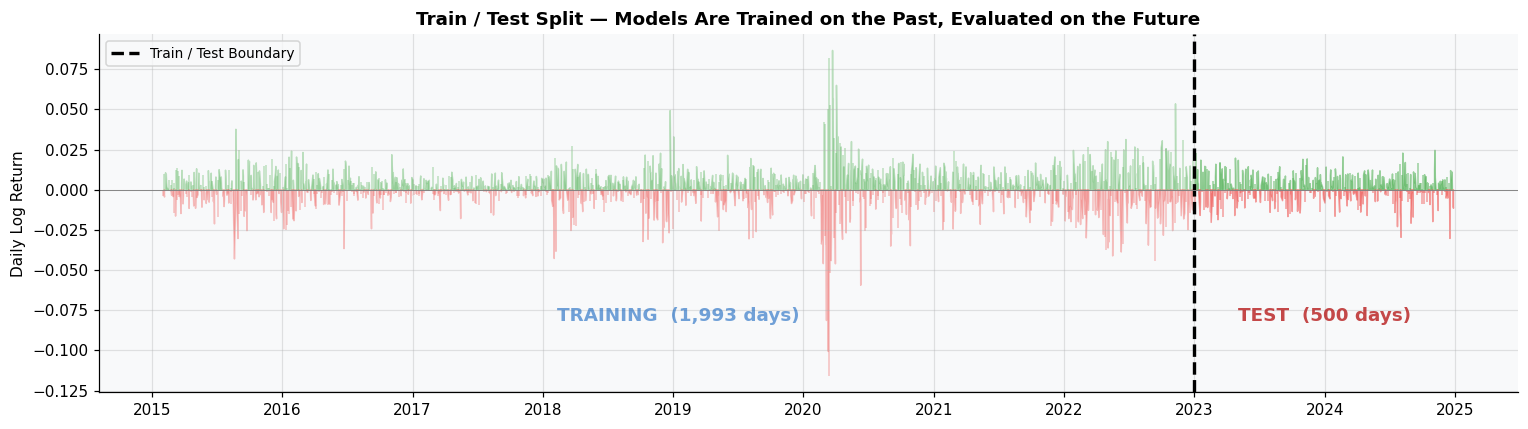

Figure saved → 03_train_test_split.png


In [10]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 5 — Train / Test Split
# ─────────────────────────────────────────────────────────────────────────────
# For time series, shuffling the data would be catastrophic:
# the model would see future returns during training and appear to
# work perfectly while doing nothing at all.
#
# We use a strict chronological split:
#   TRAIN: 2015–2022 (≈ 80%)  — model learns patterns here
#   TEST:  2023–2024 (≈ 20%)  — model is evaluated here, completely unseen
#
# The test set includes the 2022 bear market recovery, 2023 rate-hike
# environment, and 2024's AI-driven rally — a diverse range of regimes.
# This is a realistic and challenging out-of-sample evaluation.
# ─────────────────────────────────────────────────────────────────────────────
 
SPLIT_DATE = '2022-12-31'
 
train_df = features_df[features_df.index <= SPLIT_DATE]
test_df  = features_df[features_df.index >  SPLIT_DATE]
 
X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['target'].values
 
print(f"TRAIN  {len(train_df):,} days  ({train_df.index[0].date()} → {train_df.index[-1].date()})")
print(f"TEST   {len(test_df):,} days  ({test_df.index[0].date()} → {test_df.index[-1].date()})")
print(f"Features: {len(feature_cols)}")
 
# ── Visualize the split on the return series ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
 
# Fill positive/negative returns with color to make the chart readable
ax.fill_between(train_df.index, train_df['target'],
                where=train_df['target'] > 0, color='#4CAF50', alpha=0.35)
ax.fill_between(train_df.index, train_df['target'],
                where=train_df['target'] < 0, color='#EF5350', alpha=0.35)
ax.fill_between(test_df.index,  test_df['target'],
                where=test_df['target'] > 0, color='#4CAF50', alpha=0.55)
ax.fill_between(test_df.index,  test_df['target'],
                where=test_df['target'] < 0, color='#EF5350', alpha=0.55)
 
ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', lw=2.2, linestyle='--',
           label='Train / Test Boundary')
ax.axhline(0, color='grey', lw=0.6)
ax.set_title('Train / Test Split — Models Are Trained on the Past, Evaluated on the Future',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Log Return')
ax.legend(loc='upper left', fontsize=9)
 
ymin = ax.get_ylim()[0]
ax.text(train_df.index[len(train_df)//2], ymin * 0.65,
        f'TRAINING  ({len(train_df):,} days)', ha='center', fontsize=12,
        color='#1565C0', fontweight='bold', alpha=0.6)
ax.text(test_df.index[len(test_df)//2], ymin * 0.65,
        f'TEST  ({len(test_df):,} days)', ha='center', fontsize=12,
        color='#B71C1C', fontweight='bold', alpha=0.8)
 
plt.tight_layout()
plt.savefig('03_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 03_train_test_split.png")
 

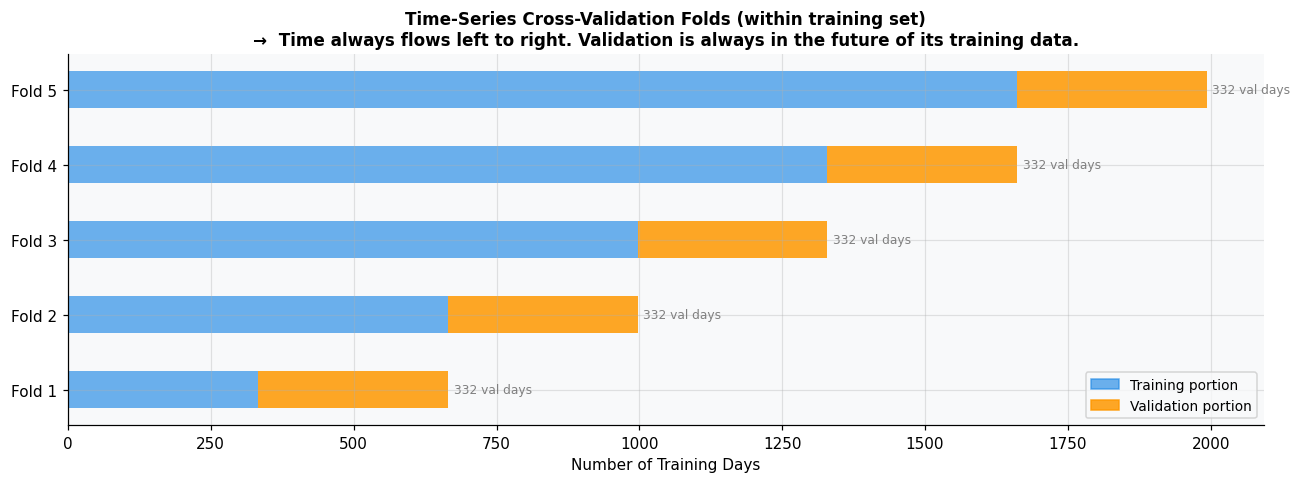

Figure saved → 04_cv_folds.png


In [11]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 6 — TimeSeriesSplit Cross-Validation (within train)
# ─────────────────────────────────────────────────────────────────────────────
# Within the training set, we use rolling/expanding-window cross-validation.
# Standard k-fold CV would mix past and future data within each fold.
# TimeSeriesSplit avoids this: each validation fold is always AFTER its
# corresponding training fold, exactly as a live system would operate.
#
# This lets us assess model stability without touching the test set.
# ─────────────────────────────────────────────────────────────────────────────
 
N_SPLITS = 5
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
 
fig, ax = plt.subplots(figsize=(12, 4.5))
colors_cv = {'train': '#1E88E5', 'val': '#FF9800'}
 
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    # Blue bar = training portion of this fold
    ax.barh(fold, len(tr_idx),
            left=0, height=0.5, color=colors_cv['train'], alpha=0.65)
    # Orange bar = validation portion (always comes after training)
    ax.barh(fold, len(val_idx),
            left=len(tr_idx), height=0.5, color=colors_cv['val'], alpha=0.85)
 
    # Label the fold
    ax.text(len(tr_idx) + len(val_idx) + 10, fold,
            f'{len(val_idx)} val days', va='center', fontsize=8, color='grey')
 
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f'Fold {i+1}' for i in range(N_SPLITS)], fontsize=10)
ax.set_xlabel('Number of Training Days')
ax.set_title(
    'Time-Series Cross-Validation Folds (within training set)\n'
    '→  Time always flows left to right. Validation is always in the future of its training data.',
    fontsize=11, fontweight='bold'
)
 
blue_patch  = mpatches.Patch(color=colors_cv['train'], alpha=0.65, label='Training portion')
oran_patch  = mpatches.Patch(color=colors_cv['val'],   alpha=0.85, label='Validation portion')
ax.legend(handles=[blue_patch, oran_patch], loc='lower right', fontsize=9)
 
plt.tight_layout()
plt.savefig('04_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 04_cv_folds.png")

In [12]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 7 — Model Definitions
# ─────────────────────────────────────────────────────────────────────────────
# Four linear models, three non-linear models.
#
# ── Linear ────────────────────────────────────────────────────────────────────
# OLS:        Pure ordinary least squares. No regularization. Baseline.
# Ridge:      L2 penalty: min ||y − Xw||² + α||w||²
#             Shrinks all coefficients toward zero; none become exactly zero.
#             Best when many features carry a little signal.
# Lasso:      L1 penalty: min ||y − Xw||² + α||w||₁
#             Drives some coefficients to exactly zero — implicit feature selection.
#             Best when only a few features are truly predictive.
# ElasticNet: Linear combination of L1 and L2. Best of both worlds.
#             l1_ratio=0.5 → equal blend.
#
# ── Non-Linear ────────────────────────────────────────────────────────────────
# RandomForest:      Ensemble of shallow decision trees via bagging.
#                    Captures feature interactions without specifying them.
#                    max_depth=4 and min_samples_leaf=20 prevent overfit.
# GradientBoosting:  Sequential trees, each correcting the residual of the last.
#                    learning_rate=0.05 + subsample=0.8 (stochastic GB) limits overfit.
# SVR (RBF):         Support Vector Regression with a radial basis function kernel.
#                    Projects features into high-dimensional space where a linear
#                    separator becomes a non-linear boundary in input space.
#                    C=1 controls margin hardness; epsilon=0.001 is the tube width.
#
# All hyperparameters are sensible defaults for noisy financial data.
# ─────────────────────────────────────────────────────────────────────────────
 
models = {
    'OLS':          LinearRegression(),
 
    'Ridge':        Ridge(alpha=1.0),
 
    'Lasso':        Lasso(alpha=5e-4, max_iter=20_000),
 
    'ElasticNet':   ElasticNet(alpha=5e-4, l1_ratio=0.5, max_iter=20_000),
 
    'RandomForest': RandomForestRegressor(
                        n_estimators=300,
                        max_depth=4,
                        min_samples_leaf=20,
                        max_features='sqrt',
                        n_jobs=-1,
                        random_state=42),
 
    'GradientBoosting': GradientBoostingRegressor(
                        n_estimators=300,
                        max_depth=3,
                        learning_rate=0.03,
                        subsample=0.8,
                        min_samples_leaf=20,
                        random_state=42),
 
    'SVR':          SVR(kernel='rbf', C=1.0, epsilon=5e-4, gamma='scale'),
}
 
print("Models registered:")
for name, model in models.items():
    tag = 'LINEAR' if name in LINEAR_MODELS else 'NON-LINEAR'
    print(f"  [{tag:10s}] {name:20s}  {type(model).__name__}")

Models registered:
  [LINEAR    ] OLS                   LinearRegression
  [LINEAR    ] Ridge                 Ridge
  [LINEAR    ] Lasso                 Lasso
  [LINEAR    ] ElasticNet            ElasticNet
  [NON-LINEAR] RandomForest          RandomForestRegressor
  [NON-LINEAR] GradientBoosting      GradientBoostingRegressor
  [NON-LINEAR] SVR                   SVR


In [13]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 8 — Scale Features, Train Models, Generate Test Predictions
# ─────────────────────────────────────────────────────────────────────────────
# WHY SCALE?
#   Ridge and Lasso penalize large coefficient values. If feature X₁ is in
#   millions (volume) and X₂ is in [0,1] (RSI/100), the penalty unfairly
#   hits X₁. Scaling to zero mean / unit variance makes the penalty fair.
#   SVR's RBF kernel computes distances — distances are meaningless without scaling.
#
# CRITICAL: the scaler is FIT on the training set ONLY.
#   We then APPLY (transform) the same scaler to the test set.
#   If we fit on train+test, we leak future distributional information.
#   This is one of the most common but subtle mistakes in ML pipelines.
# ─────────────────────────────────────────────────────────────────────────────
 
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform train
X_test_sc  = scaler.transform(X_test)        # transform only — NO refit
 
predictions = {}
 
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    predictions[name] = model.predict(X_test_sc)
    print(f"  ✅  {name:22s}  trained and predicted")
 
# Build a clean DataFrame: one column per model, plus actual returns
pred_df = pd.DataFrame(predictions, index=test_df.index)
pred_df['actual'] = y_test
 
print(f"\nPrediction DataFrame: {pred_df.shape[0]} rows × {pred_df.shape[1]} columns")
pred_df.describe().round(5)

  ✅  OLS                     trained and predicted
  ✅  Ridge                   trained and predicted
  ✅  Lasso                   trained and predicted
  ✅  ElasticNet              trained and predicted
  ✅  RandomForest            trained and predicted
  ✅  GradientBoosting        trained and predicted
  ✅  SVR                     trained and predicted

Prediction DataFrame: 500 rows × 8 columns


,OLS,Ridge,Lasso,ElasticNet,RandomForest,GradientBoosting,SVR,actual
count,500.00000,500.00000,500.00000,500.00000,500.00000,500.00000,500.00000,500.00000
mean,0.00012,0.00012,0.00038,0.00029,0.00041,0.00047,0.00021,0.00093
std,0.00188,0.00187,0.00063,0.00105,0.00047,0.00125,0.00761,0.00808
min,-0.00691,-0.00689,-0.00167,-0.00356,-0.00248,-0.00718,-0.04880,-0.03026
25%,-0.00106,-0.00106,-0.00002,-0.00034,0.00029,0.00013,-0.00245,-0.00323
50%,0.00017,0.00018,0.00038,0.00030,0.00031,0.00018,0.00086,0.00096
75%,0.00133,0.00133,0.00074,0.00091,0.00042,0.00059,0.00387,0.00599
max,0.00559,0.00558,0.00270,0.00360,0.00412,0.00877,0.03858,0.02456


In [14]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 9 — Evaluation Metrics
# ─────────────────────────────────────────────────────────────────────────────
# We evaluate on four axes:
#
# 1. RMSE — Root Mean Squared Error
#    Standard ML metric. Penalizes large errors heavily.
#    Useful but not the primary metric in finance (magnitude is very hard to predict).
#
# 2. IC — Information Coefficient  (Spearman rank correlation)
#    *** The industry standard metric for quant signals ***
#    Asks: does the RANKING of our predictions match the ranking of actual returns?
#    Perfect ordering = IC of 1. Random = IC of 0.
#    Even IC ≈ 0.03–0.05 is considered commercially viable in the industry.
#    Scale-free: doesn't require accurate magnitude, only correct direction of ranking.
#    Uses Spearman (rank-based) rather than Pearson to be robust to outliers.
#
# 3. Hit Rate — Directional Accuracy
#    % of days where we correctly call UP vs DOWN.
#    A random model scores 50%. Anything above 52–53% is meaningful in practice.
#
# 4. Annualized Sharpe Ratio (of a long/short signal strategy)
#    We go LONG when prediction > 0, SHORT when prediction < 0.
#    PnL = sign(prediction) × actual_return.
#    Sharpe = mean(PnL) / std(PnL) × √252.
#    This ties the signal directly to a P&L outcome — what a PM cares about.
#    We also compute a net-of-transaction-cost Sharpe (5 bps per round-trip,
#    realistic for liquid ETFs like SPY).
# ─────────────────────────────────────────────────────────────────────────────
 
TC_PER_TRADE = 0.0005  # 5 basis points (one-way), realistic for SPY
 
def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute the four key metrics for a return prediction model."""
 
    # 1. RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
 
    # 2. IC (Spearman rank correlation)
    ic, _ = spearmanr(y_true, y_pred)
 
    # 3. Hit rate: fraction of correct directional calls
    hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
 
    # 4. Long/short strategy PnL
    pnl = np.sign(y_pred) * y_true
 
    # Gross Sharpe (before transaction costs)
    sharpe_gross = (pnl.mean() / (pnl.std() + 1e-9)) * np.sqrt(252)
 
    # Net Sharpe: deduct TC on each trade (we trade every day in this strategy)
    pnl_net = pnl - TC_PER_TRADE  # 5bps cost per day regardless of direction
    sharpe_net = (pnl_net.mean() / (pnl_net.std() + 1e-9)) * np.sqrt(252)
 
    return {
        'RMSE':          rmse,
        'IC':            ic,
        'Hit Rate':      hit_rate,
        'Sharpe':        sharpe_gross,
        'Sharpe (net)':  sharpe_net,
    }
 
 
results = {name: evaluate(y_test, predictions[name]) for name in models}
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df['Type'] = ['Linear' if m in LINEAR_MODELS else 'Non-Linear'
                      for m in results_df.index]
 
# Compute Buy & Hold Sharpe as benchmark reference
bh_pnl     = y_test                          # always long
bh_sharpe  = (bh_pnl.mean() / bh_pnl.std()) * np.sqrt(252)
 
print("=" * 65)
print("  OUT-OF-SAMPLE PERFORMANCE SUMMARY")
print("=" * 65)
print(results_df[['RMSE', 'IC', 'Hit Rate', 'Sharpe', 'Sharpe (net)']].to_string(
    float_format=lambda x: f'{x:>8.4f}'))
print(f"\n  Buy & Hold Sharpe (benchmark): {bh_sharpe:.4f}")
print("=" * 65)
 

  OUT-OF-SAMPLE PERFORMANCE SUMMARY
                     RMSE       IC  Hit Rate   Sharpe  Sharpe (net)
Model                                                              
OLS                0.0083  -0.0014    0.5080   0.4332       -0.5438
Ridge              0.0083  -0.0014    0.5080   0.4432       -0.5339
Lasso              0.0081   0.0088    0.5360   0.4199       -0.5571
ElasticNet         0.0082  -0.0191    0.5020  -0.4694       -1.4465
RandomForest       0.0081   0.0727    0.5480   1.1822        0.2029
GradientBoosting   0.0082   0.0111    0.5520   0.7854       -0.1924
SVR                0.0113  -0.0153    0.4940  -0.0309       -1.0075

  Buy & Hold Sharpe (benchmark): 1.8191


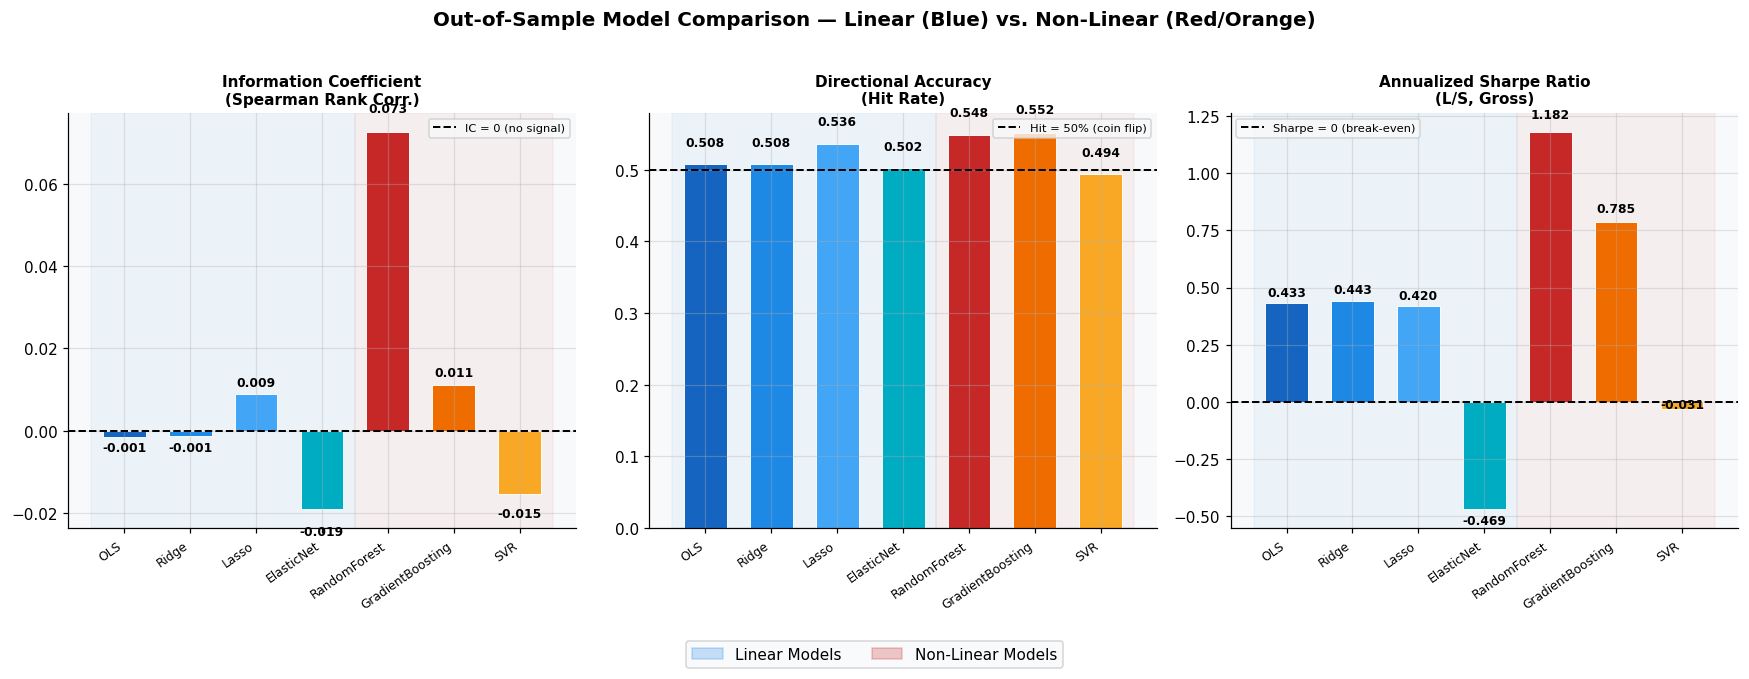

Figure saved → 05_model_comparison_bars.png


In [15]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 10 — Bar Chart Comparison: IC, Hit Rate, Sharpe
# ─────────────────────────────────────────────────────────────────────────────
# A visual comparison across all three key metrics.
# Threshold dashed lines give context: what is "good enough" in practice?
# Blue background shading = linear model region.
# Red background shading  = non-linear model region.
# ─────────────────────────────────────────────────────────────────────────────
 
metrics_cfg = {
    'IC':         ('Information Coefficient\n(Spearman Rank Corr.)',  0.0,  'IC = 0 (no signal)'),
    'Hit Rate':   ('Directional Accuracy\n(Hit Rate)',                0.50, 'Hit = 50% (coin flip)'),
    'Sharpe':     ('Annualized Sharpe Ratio\n(L/S, Gross)',           0.0,  'Sharpe = 0 (break-even)'),
}
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Out-of-Sample Model Comparison — Linear (Blue) vs. Non-Linear (Red/Orange)',
             fontsize=13, fontweight='bold', y=1.02)
 
model_names = list(models.keys())
x_pos       = np.arange(len(model_names))
bar_colors  = [PALETTE[m] for m in model_names]
 
for ax, (metric, (title, threshold, threshold_label)) in zip(axes, metrics_cfg.items()):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x_pos, vals, color=bar_colors, edgecolor='white', linewidth=0.6, width=0.65)
 
    # Threshold reference line
    ax.axhline(threshold, color='black', lw=1.3, linestyle='--', label=threshold_label)
 
    # Value labels above/below bars
    for bar, val in zip(bars, vals):
        yoff = abs(val) * 0.04 + 0.001
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (yoff if val >= 0 else -yoff*4),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
 
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
    ax.legend(fontsize=7.5, loc='best')
 
    # Background shading for model-type regions
    n_lin = len(LINEAR_MODELS)
    ax.axvspan(-0.5, n_lin - 0.5,          alpha=0.05, color='#1E88E5', zorder=0)
    ax.axvspan(n_lin - 0.5, len(model_names) - 0.5, alpha=0.05, color='#C62828', zorder=0)
 
# Legend for model type shading
lin_patch  = mpatches.Patch(color='#1E88E5', alpha=0.25, label='Linear Models')
nlin_patch = mpatches.Patch(color='#C62828', alpha=0.25, label='Non-Linear Models')
fig.legend(handles=[lin_patch, nlin_patch], loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.08))
 
plt.tight_layout()
plt.savefig('05_model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 05_model_comparison_bars.png")
 

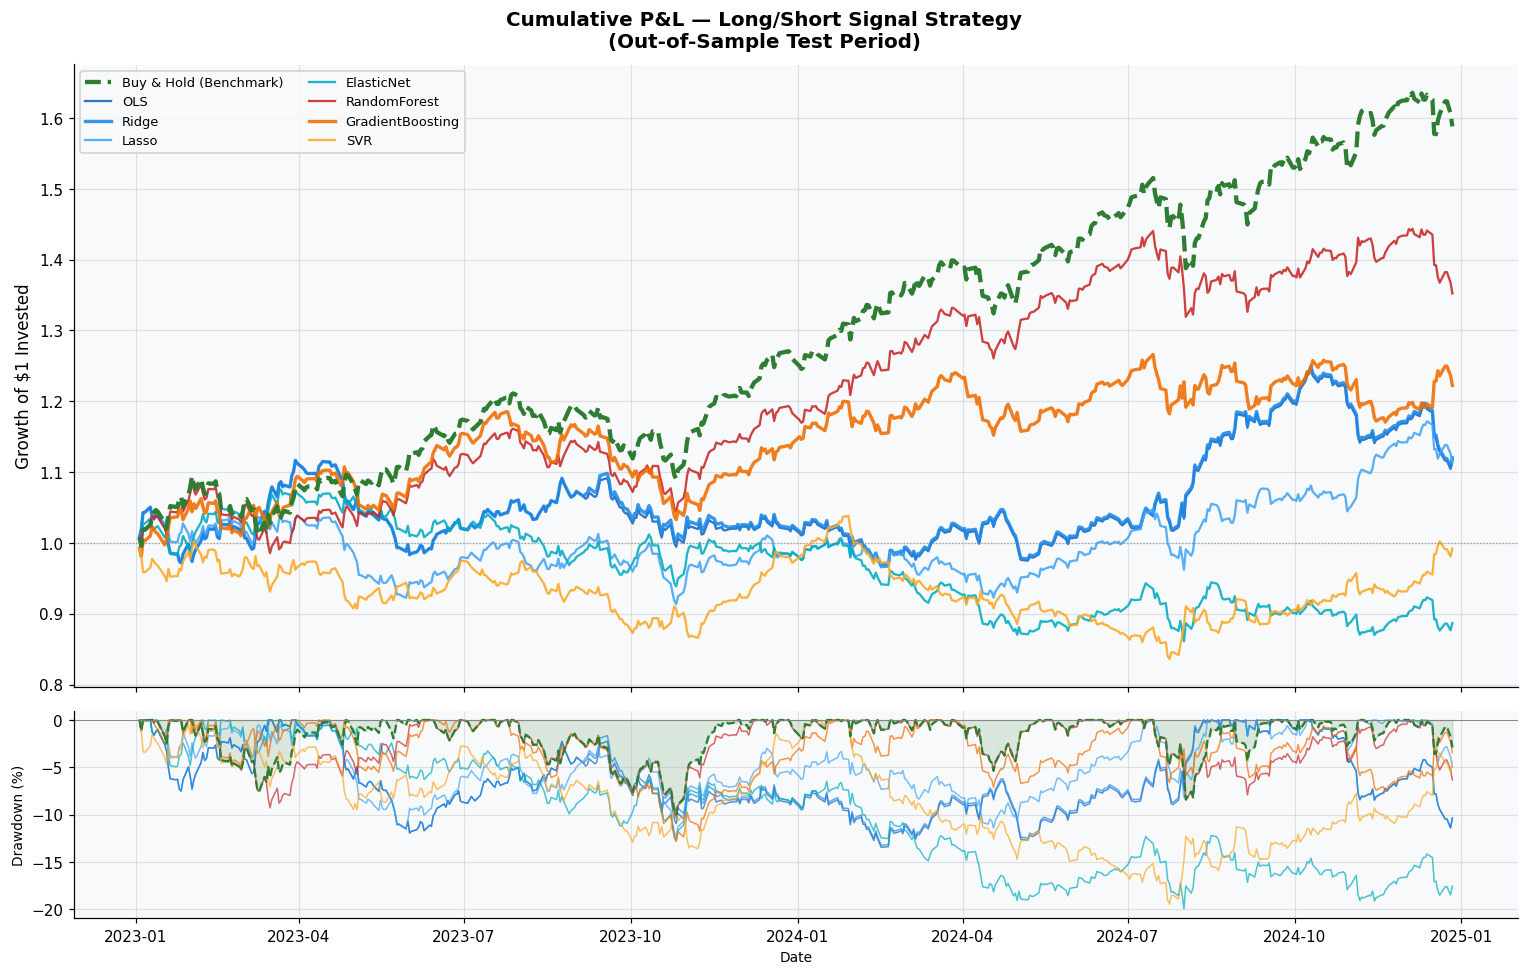

Figure saved → 06_cumulative_pnl.png


In [16]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 11 — Cumulative P&L: The Backtest
# ─────────────────────────────────────────────────────────────────────────────
# We simulate a simple long/short strategy:
#   • Prediction > 0  →  go LONG SPY (buy)
#   • Prediction < 0  →  go SHORT SPY (sell short)
#   • Hold exactly one day, rebalance at next close.
#
# Cumulative value = exp(Σ sign(pred_t) × r_actual_t)
# Starting value = $1 for all strategies.
#
# This is the most intuitive metric for non-technical stakeholders:
# "If you had followed this model's signals with $1, what would you have now?"
# A model below $1 lost money. Buy & Hold is the passive benchmark.
# ─────────────────────────────────────────────────────────────────────────────
 
fig, (ax_main, ax_dd) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Cumulative P&L — Long/Short Signal Strategy\n(Out-of-Sample Test Period)',
             fontsize=13, fontweight='bold')
 
# ── Buy & Hold benchmark ───────────────────────────────────────────────────────
bh_cum = np.exp(np.cumsum(y_test))
ax_main.plot(test_df.index, bh_cum, color=PALETTE['BuyAndHold'],
             lw=2.8, linestyle='--', label='Buy & Hold (Benchmark)', zorder=6)
 
# ── Model strategies ──────────────────────────────────────────────────────────
cum_pnl_dict = {}
for name in model_names:
    daily_pnl   = np.sign(predictions[name]) * y_test
    cum_pnl     = np.exp(np.cumsum(daily_pnl))
    cum_pnl_dict[name] = cum_pnl
    lw = 2.2 if name in ['GradientBoosting', 'Ridge'] else 1.5
    ax_main.plot(test_df.index, cum_pnl, color=PALETTE[name],
                 lw=lw, label=name, alpha=0.88)
 
ax_main.axhline(1.0, color='grey', lw=0.8, linestyle=':', alpha=0.7)
ax_main.set_ylabel('Growth of $1 Invested', fontsize=11)
ax_main.legend(loc='upper left', fontsize=8.5, framealpha=0.92, ncol=2)
ax_main.set_title('')
 
# ── Drawdown chart (bottom panel) ─────────────────────────────────────────────
# Drawdown = how far below the peak is the strategy at any point?
# Max drawdown is a key risk metric used by every allocator.
for name in model_names:
    cum   = pd.Series(cum_pnl_dict[name], index=test_df.index)
    peak  = cum.cummax()
    dd    = (cum - peak) / peak
    ax_dd.plot(test_df.index, dd * 100, color=PALETTE[name], lw=1.0, alpha=0.7)
 
# Buy & Hold drawdown
bh_s   = pd.Series(bh_cum, index=test_df.index)
bh_dd  = (bh_s - bh_s.cummax()) / bh_s.cummax()
ax_dd.fill_between(test_df.index, bh_dd * 100, 0,
                   color=PALETTE['BuyAndHold'], alpha=0.15, label='B&H Drawdown')
ax_dd.plot(test_df.index, bh_dd * 100, color=PALETTE['BuyAndHold'], lw=1.5, linestyle='--')
ax_dd.set_ylabel('Drawdown (%)', fontsize=9)
ax_dd.set_xlabel('Date', fontsize=9)
ax_dd.axhline(0, color='grey', lw=0.6)
 
plt.tight_layout()
plt.savefig('06_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 06_cumulative_pnl.png")

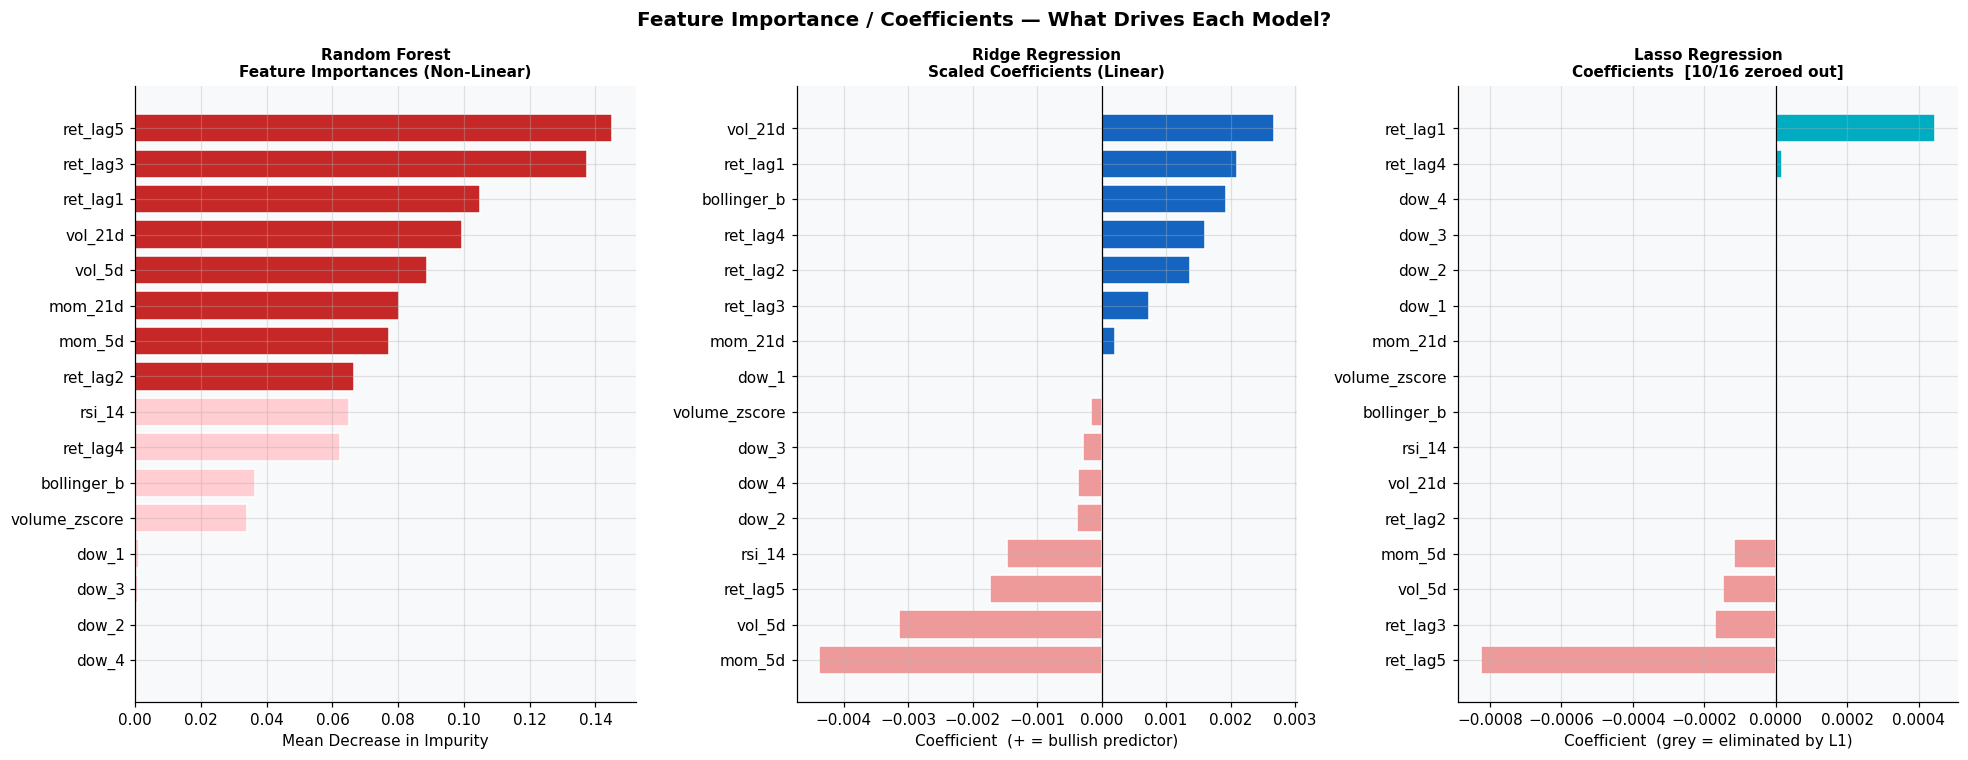

Figure saved → 07_feature_importance.png
Lasso eliminated 10 of 16 features via L1 sparsity.


In [17]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 12 — Feature Importance vs. Model Coefficients
# ─────────────────────────────────────────────────────────────────────────────
# Linear models: coefficients tell us the marginal effect of each feature
#   on the prediction (after scaling, so coefficients are comparable).
#   A positive Ridge coefficient → "higher value of this feature → bullish signal."
#   A coefficient of zero (Lasso) → "this feature was eliminated."
#
# Random Forest: feature importance = mean decrease in impurity (MDI).
#   How much on average does splitting on this feature reduce prediction error?
#   Higher = more important.
#
# This is diagnostically valuable: if the model leans on lagged returns,
# it suggests momentum. If it leans on volatility, it's a regime signal.
# ─────────────────────────────────────────────────────────────────────────────
 
rf_model    = models['RandomForest']
ridge_model = models['Ridge']
lasso_model = models['Lasso']
 
rf_imp     = rf_model.feature_importances_
ridge_coef = ridge_model.coef_
lasso_coef = lasso_model.coef_
 
# Sort for readability
rf_df    = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_imp}).sort_values('Importance')
ridge_df = pd.DataFrame({'Feature': feature_cols, 'Coeff': ridge_coef}).sort_values('Coeff')
lasso_df = pd.DataFrame({'Feature': feature_cols, 'Coeff': lasso_coef}).sort_values('Coeff')
 
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Feature Importance / Coefficients — What Drives Each Model?',
             fontsize=13, fontweight='bold')
 
# ── Random Forest importance ──────────────────────────────────────────────────
ax = axes[0]
thresh = np.median(rf_imp)
colors_rf = ['#C62828' if v >= thresh else '#FFCDD2' for v in rf_df['Importance']]
ax.barh(rf_df['Feature'], rf_df['Importance'], color=colors_rf, edgecolor='white')
ax.set_title('Random Forest\nFeature Importances (Non-Linear)', fontsize=10, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
 
# ── Ridge coefficients ─────────────────────────────────────────────────────────
ax = axes[1]
colors_ridge = ['#1565C0' if v >= 0 else '#EF9A9A' for v in ridge_df['Coeff']]
ax.barh(ridge_df['Feature'], ridge_df['Coeff'], color=colors_ridge, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Ridge Regression\nScaled Coefficients (Linear)', fontsize=10, fontweight='bold')
ax.set_xlabel('Coefficient  (+ = bullish predictor)')
 
# ── Lasso coefficients — shows sparsity ───────────────────────────────────────
ax = axes[2]
colors_lasso = ['#00ACC1' if v > 0 else ('#EF9A9A' if v < 0 else '#E0E0E0')
                for v in lasso_df['Coeff']]
ax.barh(lasso_df['Feature'], lasso_df['Coeff'], color=colors_lasso, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
n_zero = (lasso_coef == 0).sum()
ax.set_title(f'Lasso Regression\nCoefficients  [{n_zero}/{len(feature_cols)} zeroed out]',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Coefficient  (grey = eliminated by L1)')
 
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → 07_feature_importance.png")
print(f"Lasso eliminated {n_zero} of {len(feature_cols)} features via L1 sparsity.")
 

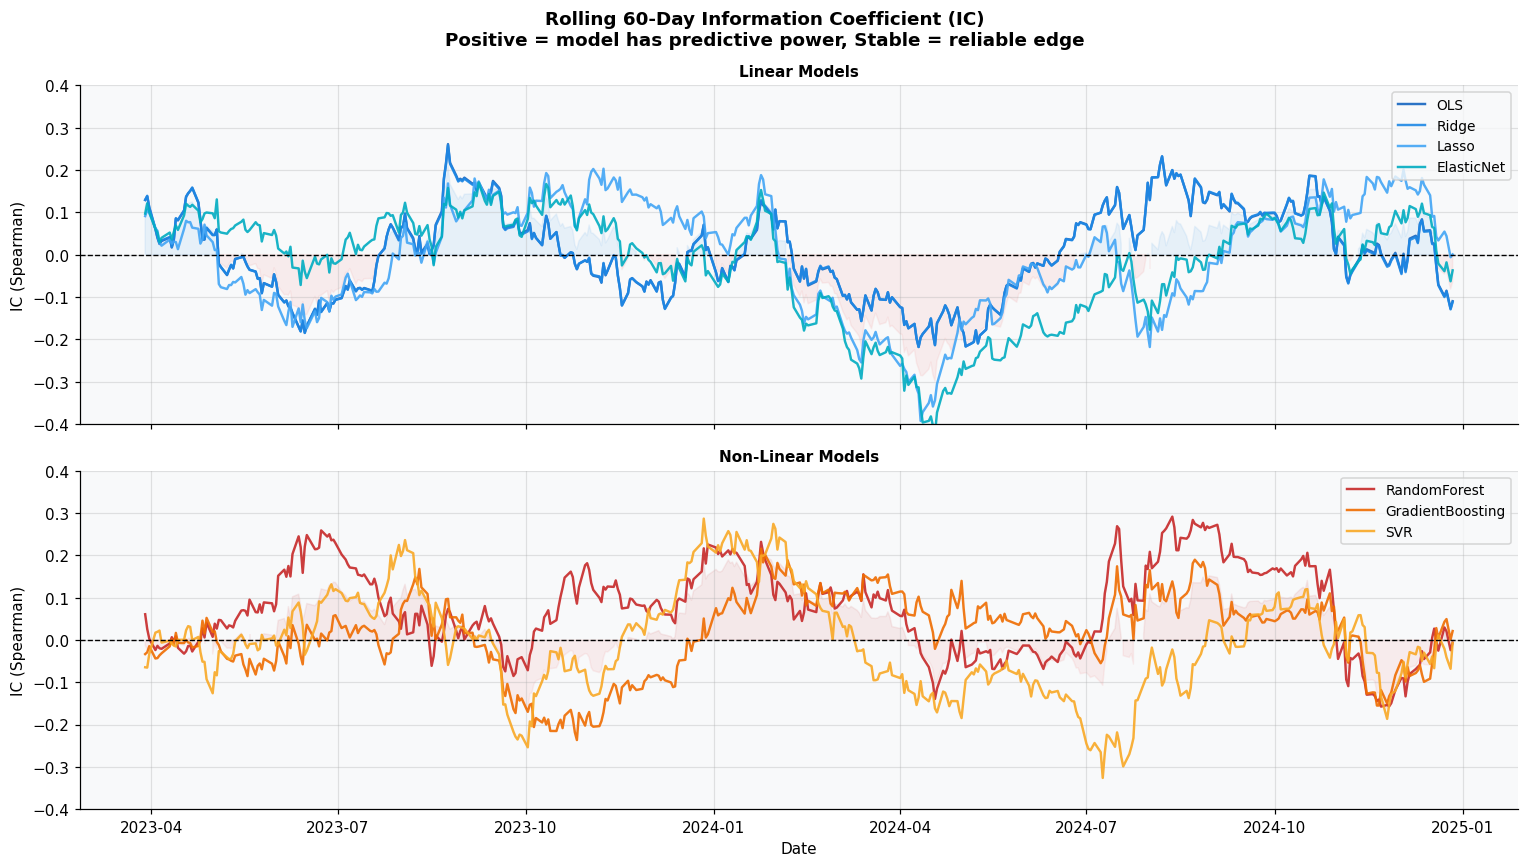

Figure saved → 08_rolling_ic.png


In [18]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 13 — Rolling Information Coefficient: Signal Stability Over Time
# ─────────────────────────────────────────────────────────────────────────────
# A high AVERAGE IC can be misleading. If the model only works during
# a trending regime and fails during mean-reverting periods, a portfolio
# manager cannot rely on it consistently.
#
# Rolling IC shows whether the signal is stable across market regimes:
#   • Positive + stable → durable edge (most desirable)
#   • Positive + spiky  → regime-dependent (less reliable)
#   • Mean ≈ 0          → no persistent edge
#
# Factor desks at quant funds track rolling IC continuously.
# Signal decay — IC trending toward zero over time — is a key concern.
#
# We use a 60-day rolling window (≈ 3 calendar months).
# ─────────────────────────────────────────────────────────────────────────────
 
ROLL_WINDOW = 60
 
def rolling_spearman(arr_pred: np.ndarray, arr_act: np.ndarray,
                     index: pd.DatetimeIndex, window: int) -> pd.Series:
    """
    Rolling Spearman IC.
    At each time t, compute Spearman rank correlation of
    predictions and actuals in the window [t-window+1, t].
    """
    n  = len(arr_pred)
    ic = np.full(n, np.nan)
    for i in range(window - 1, n):
        rho, _ = spearmanr(
            arr_pred[i - window + 1 : i + 1],
            arr_act [i - window + 1 : i + 1]
        )
        ic[i] = rho
    return pd.Series(ic, index=index)
 
 
roll_ic = {
    name: rolling_spearman(predictions[name], y_test, test_df.index, ROLL_WINDOW)
    for name in model_names
}
 
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Rolling {ROLL_WINDOW}-Day Information Coefficient (IC)\n'
             'Positive = model has predictive power, Stable = reliable edge',
             fontsize=12, fontweight='bold')
 
# ── Linear models (top panel) ─────────────────────────────────────────────────
for name in LINEAR_MODELS:
    ax_top.plot(roll_ic[name].index, roll_ic[name].values,
                color=PALETTE[name], lw=1.6, label=name, alpha=0.9)
avg_lin = pd.concat([roll_ic[n] for n in LINEAR_MODELS], axis=1).mean(axis=1)
ax_top.fill_between(avg_lin.index, 0, avg_lin.values,
                    where=avg_lin.values > 0, alpha=0.08, color='#1E88E5')
ax_top.fill_between(avg_lin.index, 0, avg_lin.values,
                    where=avg_lin.values < 0, alpha=0.08, color='#EF5350')
ax_top.axhline(0, color='black', lw=0.9, linestyle='--')
ax_top.set_title('Linear Models', fontsize=10, fontweight='bold')
ax_top.set_ylabel('IC (Spearman)')
ax_top.set_ylim(-0.4, 0.4)
ax_top.legend(fontsize=9, loc='upper right')
 
# ── Non-linear models (bottom panel) ──────────────────────────────────────────
for name in NONLINEAR_MODELS:
    ax_bot.plot(roll_ic[name].index, roll_ic[name].values,
                color=PALETTE[name], lw=1.6, label=name, alpha=0.9)
avg_nlin = pd.concat([roll_ic[n] for n in NONLINEAR_MODELS], axis=1).mean(axis=1)
ax_bot.fill_between(avg_nlin.index, 0, avg_nlin.values,
                    where=avg_nlin.values > 0, alpha=0.08, color='#C62828')
ax_bot.fill_between(avg_nlin.index, 0, avg_nlin.values,
                    where=avg_nlin.values < 0, alpha=0.08, color='#EF5350')
ax_bot.axhline(0, color='black', lw=0.9, linestyle='--')
ax_bot.set_title('Non-Linear Models', fontsize=10, fontweight='bold')
ax_bot.set_ylabel('IC (Spearman)')
ax_bot.set_xlabel('Date')
ax_bot.set_ylim(-0.4, 0.4)
ax_bot.legend(fontsize=9, loc='upper right')
 
plt.tight_layout()
plt.savefig('08_rolling_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 08_rolling_ic.png")
 

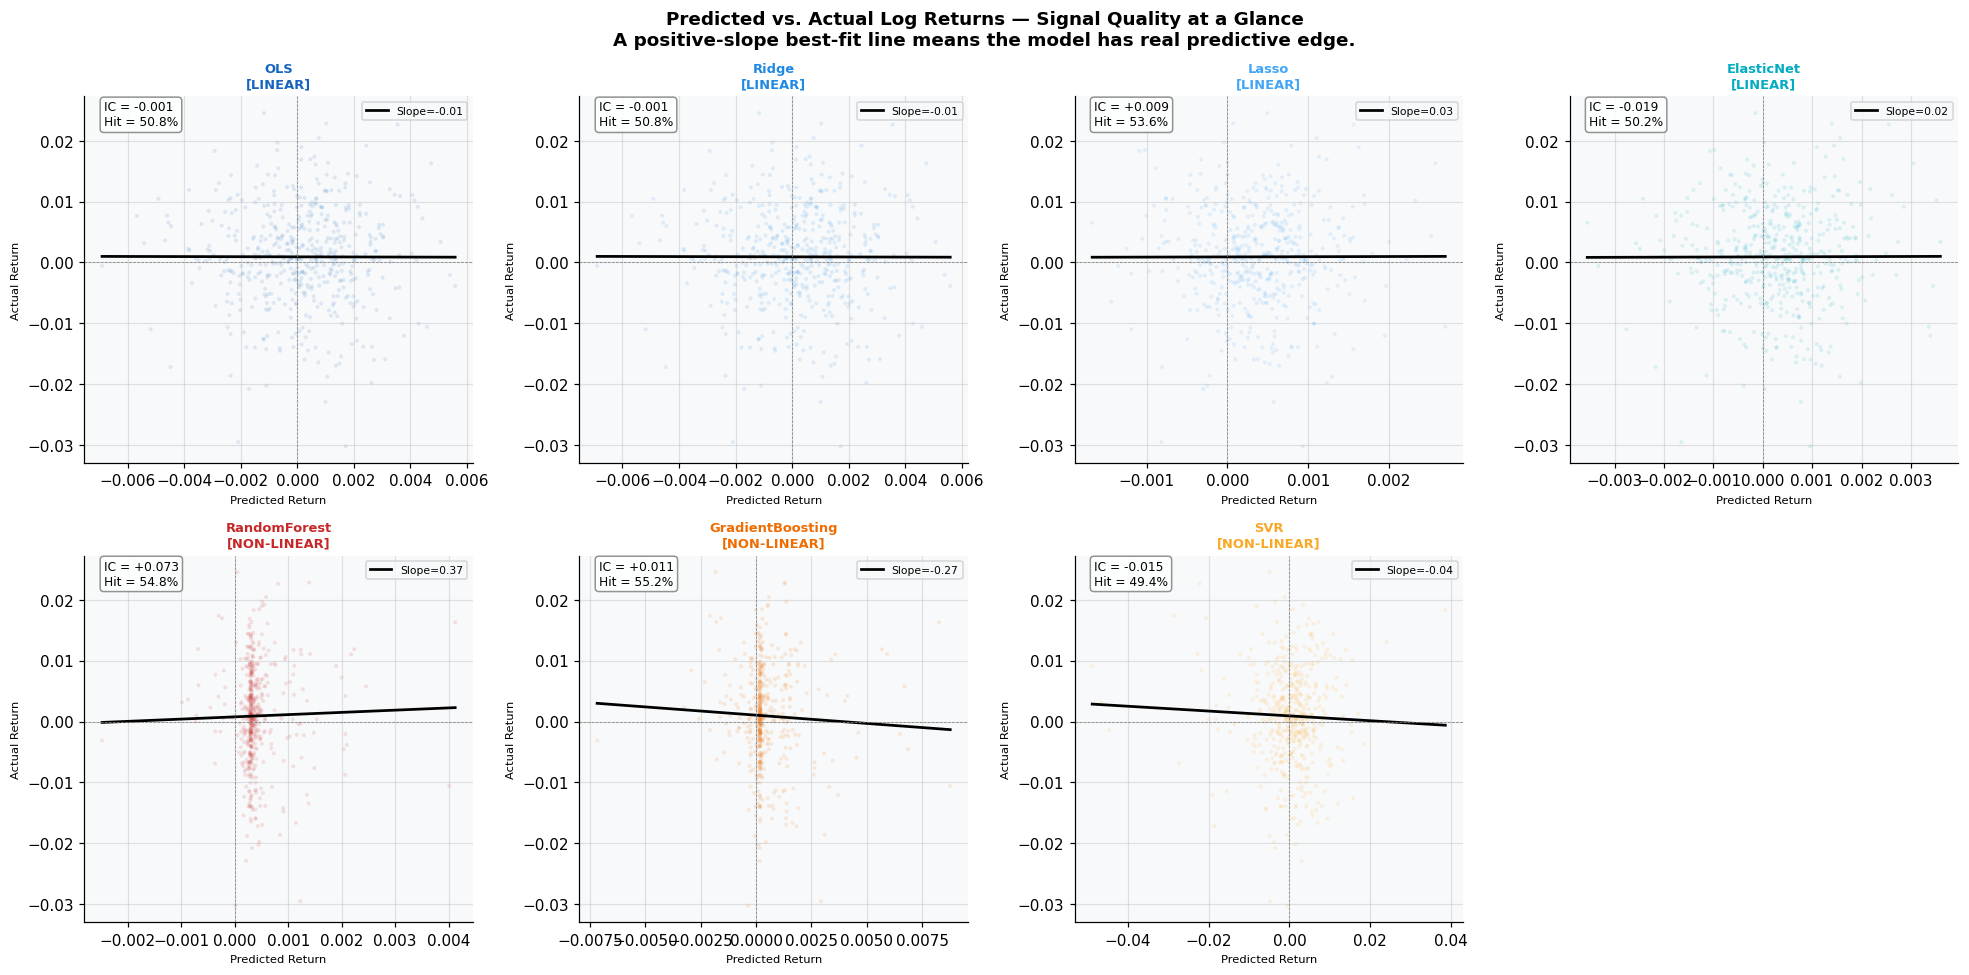

Figure saved → 09_scatter_predicted_actual.png


In [19]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 14 — Predicted vs. Actual Scatter Plots
# ─────────────────────────────────────────────────────────────────────────────
# Plotting predicted return against actual return gives a visual intuition
# for signal quality.
#
# If the model were perfect, all points would lie on a 45-degree line.
# In reality, equity return prediction is extremely noisy: even a strong
# quant signal explains only 2–5% of variance (R² ≈ 0.02–0.05).
# What we look for is a POSITIVE SLOPE in the best-fit line: on average,
# when the model predicts up, the market does go up.
#
# A flat best-fit line → no signal.
# A negative slope → the model is anti-predictive (still exploitable,
# but you'd go opposite to its signal).
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()
fig.suptitle('Predicted vs. Actual Log Returns — Signal Quality at a Glance\n'
             'A positive-slope best-fit line means the model has real predictive edge.',
             fontsize=12, fontweight='bold')
 
for ax, name in zip(axes_flat, model_names):
    y_pred = predictions[name]
    ic_val = results[name]['IC']
    hr_val = results[name]['Hit Rate']
 
    ax.scatter(y_pred, y_test, alpha=0.12, s=7, color=PALETTE[name], edgecolors='none')
 
    # Best-fit line via OLS on the scatter
    m, b = np.polyfit(y_pred, y_test, 1)
    xr = np.linspace(y_pred.min(), y_pred.max(), 200)
    ax.plot(xr, m*xr + b, color='black', lw=1.8, label=f'Slope={m:.2f}')
 
    ax.axhline(0, color='grey', lw=0.5, linestyle='--')
    ax.axvline(0, color='grey', lw=0.5, linestyle='--')
 
    tag = 'LINEAR' if name in LINEAR_MODELS else 'NON-LINEAR'
    ax.set_title(f'{name}\n[{tag}]', fontsize=8.5, fontweight='bold', color=PALETTE[name])
    ax.set_xlabel('Predicted Return', fontsize=7.5)
    ax.set_ylabel('Actual Return', fontsize=7.5)
    ax.text(0.05, 0.92,
            f'IC = {ic_val:+.3f}\nHit = {hr_val:.1%}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='grey'))
    ax.legend(fontsize=7)
 
# Hide the 8th subplot (we have 7 models, 2×4 = 8 slots)
axes_flat[-1].set_visible(False)
 
plt.tight_layout()
plt.savefig('09_scatter_predicted_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 09_scatter_predicted_actual.png")
 

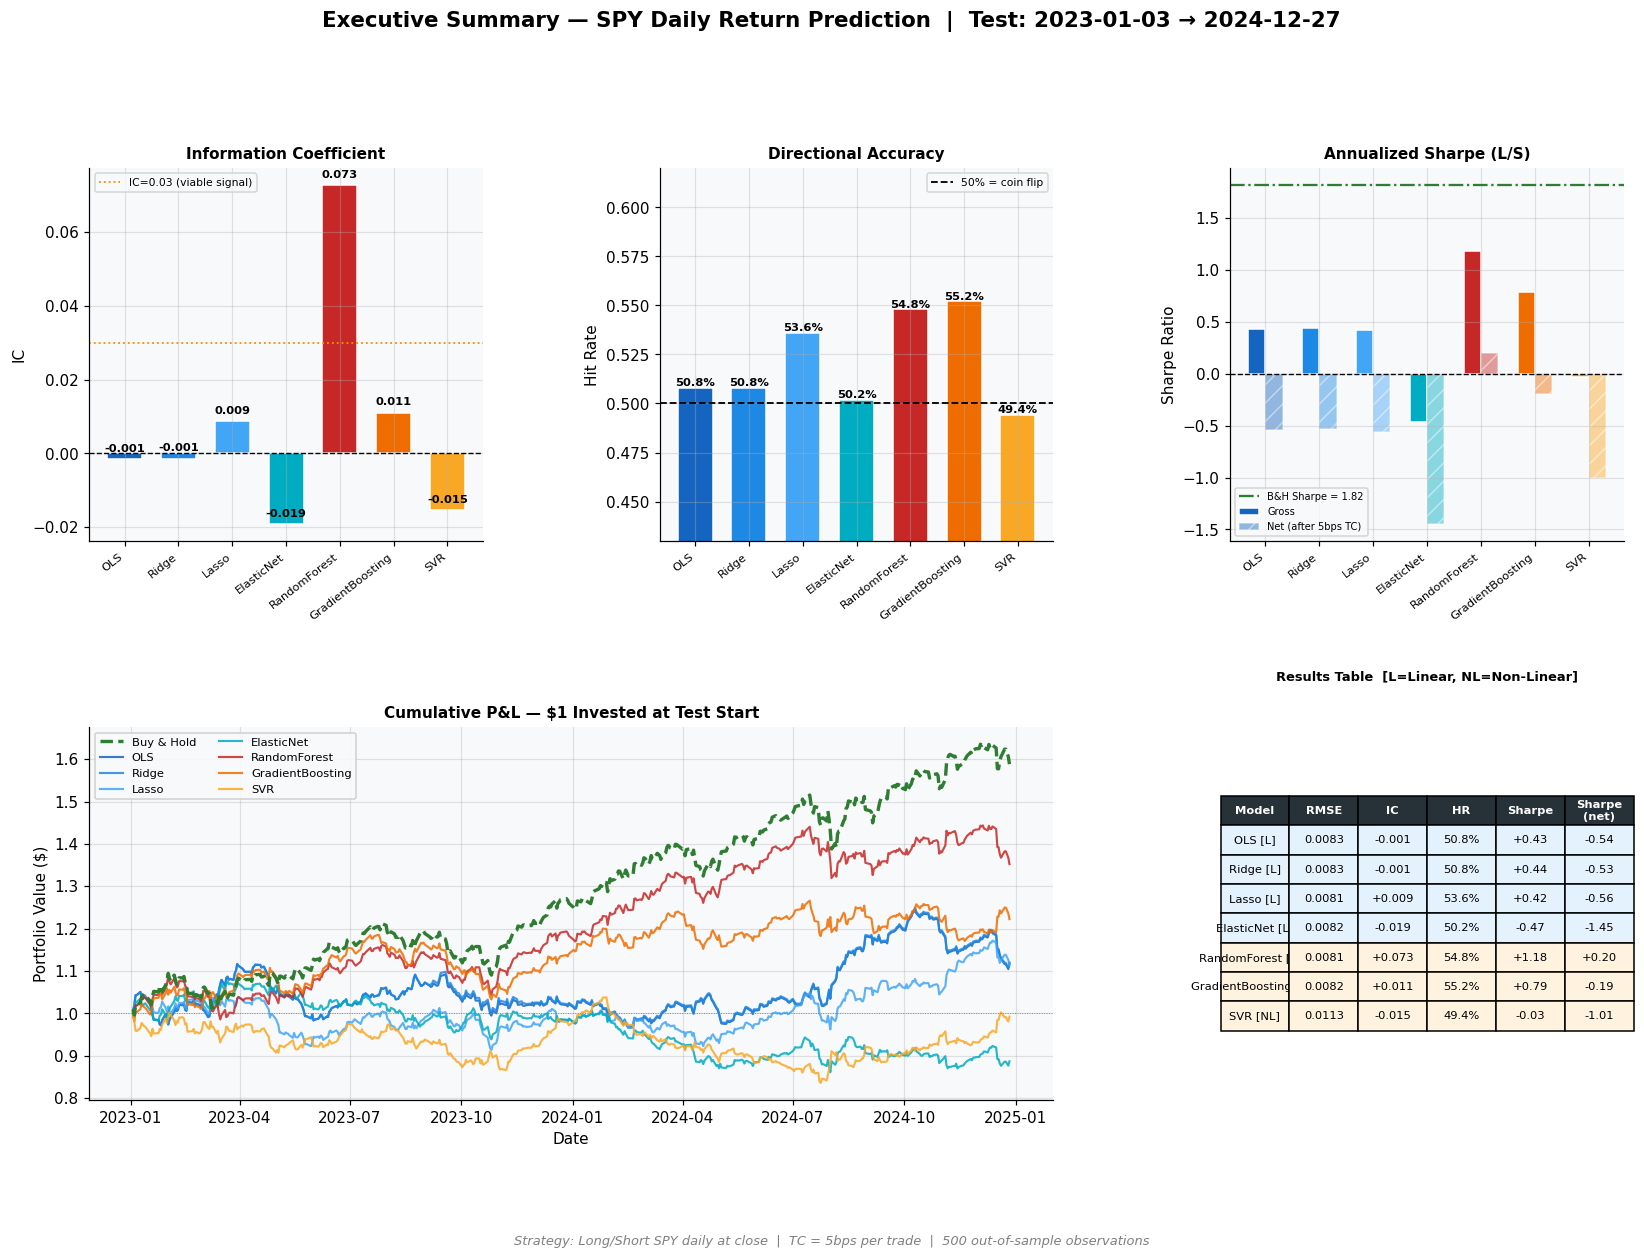

Figure saved → 10_executive_summary.png

✅  All 10 figures generated. Full notebook complete.


In [20]:
# %% ─────────────────────────────────────────────────────────────────────────
# BLOCK 15 — Executive Summary Dashboard
# ─────────────────────────────────────────────────────────────────────────────
# A single-page summary: the kind of slide a quant PM or researcher would
# present to a portfolio committee or investment review board.
#
# Non-technical takeaway: which bar/line is tallest / most profitable?
# Technical takeaway: IC, Sharpe, and the full results table with TC costs.
# ─────────────────────────────────────────────────────────────────────────────
 
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.45)
fig.suptitle(
    f'Executive Summary — {TICKER} Daily Return Prediction  |  '
    f'Test: {test_df.index[0].date()} → {test_df.index[-1].date()}',
    fontsize=14, fontweight='bold', y=1.01
)
 
x_pos      = np.arange(len(model_names))
bar_colors = [PALETTE[m] for m in model_names]
 
# ── Panel A: IC ───────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ic_vals = [results[m]['IC'] for m in model_names]
bars = ax0.bar(x_pos, ic_vals, color=bar_colors, edgecolor='white', width=0.65)
ax0.axhline(0,    color='black', lw=0.9, linestyle='--')
ax0.axhline(0.03, color='darkorange', lw=1.2, linestyle=':', label='IC=0.03 (viable signal)')
for bar, v in zip(bars, ic_vals):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{v:.3f}', ha='center', fontsize=7.5, fontweight='bold')
ax0.set_title('Information Coefficient', fontweight='bold', fontsize=10)
ax0.set_xticks(x_pos); ax0.set_xticklabels(model_names, rotation=38, ha='right', fontsize=7.5)
ax0.legend(fontsize=7)
ax0.set_ylabel('IC')
 
# ── Panel B: Hit Rate ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
hr_vals = [results[m]['Hit Rate'] for m in model_names]
bars = ax1.bar(x_pos, hr_vals, color=bar_colors, edgecolor='white', width=0.65)
ax1.axhline(0.50, color='black', lw=1.2, linestyle='--', label='50% = coin flip')
for bar, v in zip(bars, hr_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{v:.1%}', ha='center', fontsize=7.5, fontweight='bold')
ax1.set_title('Directional Accuracy', fontweight='bold', fontsize=10)
ax1.set_xticks(x_pos); ax1.set_xticklabels(model_names, rotation=38, ha='right', fontsize=7.5)
ax1.legend(fontsize=7)
ax1.set_ylim(0.43, 0.62)
ax1.set_ylabel('Hit Rate')
 
# ── Panel C: Gross vs. Net Sharpe ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sh_gross = [results[m]['Sharpe']       for m in model_names]
sh_net   = [results[m]['Sharpe (net)'] for m in model_names]
w = 0.32
b1 = ax2.bar(x_pos - w/2, sh_gross, width=w, color=bar_colors, edgecolor='white', label='Gross')
b2 = ax2.bar(x_pos + w/2, sh_net,   width=w, color=bar_colors, edgecolor='white',
             alpha=0.45, hatch='//', label='Net (after 5bps TC)')
ax2.axhline(0,         color='black',               lw=0.9, linestyle='--')
ax2.axhline(bh_sharpe, color=PALETTE['BuyAndHold'], lw=1.5, linestyle='-.',
            label=f'B&H Sharpe = {bh_sharpe:.2f}')
ax2.set_title('Annualized Sharpe (L/S)', fontweight='bold', fontsize=10)
ax2.set_xticks(x_pos); ax2.set_xticklabels(model_names, rotation=38, ha='right', fontsize=7.5)
ax2.legend(fontsize=6.5)
ax2.set_ylabel('Sharpe Ratio')
 
# ── Panel D: Cumulative P&L ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
bh_cum = np.exp(np.cumsum(y_test))
ax3.plot(test_df.index, bh_cum, color=PALETTE['BuyAndHold'], lw=2.2,
         linestyle='--', label='Buy & Hold', zorder=5)
for name in model_names:
    cum = np.exp(np.cumsum(np.sign(predictions[name]) * y_test))
    ax3.plot(test_df.index, cum, color=PALETTE[name], lw=1.4, label=name, alpha=0.85)
ax3.axhline(1.0, color='grey', lw=0.6, linestyle=':')
ax3.set_title('Cumulative P&L — $1 Invested at Test Start', fontweight='bold', fontsize=10)
ax3.set_ylabel('Portfolio Value ($)')
ax3.set_xlabel('Date')
ax3.legend(fontsize=7.5, ncol=2, loc='upper left', framealpha=0.9)
 
# ── Panel E: Results Table ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
 
table_rows = []
for name in model_names:
    r = results[name]
    tag = 'L' if name in LINEAR_MODELS else 'NL'
    table_rows.append([
        f'{name} [{tag}]',
        f'{r["RMSE"]:.4f}',
        f'{r["IC"]:+.3f}',
        f'{r["Hit Rate"]:.1%}',
        f'{r["Sharpe"]:+.2f}',
        f'{r["Sharpe (net)"]:+.2f}',
    ])
 
tbl = ax4.table(
    cellText=table_rows,
    colLabels=['Model', 'RMSE', 'IC', 'HR', 'Sharpe', 'Sharpe\n(net)'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1.05, 1.6)
 
# Style header row
for j in range(6):
    tbl[0, j].set_facecolor('#263238')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
 
# Style model rows — light blue for linear, light red for non-linear
for i, name in enumerate(model_names, start=1):
    bg = '#E3F2FD' if name in LINEAR_MODELS else '#FFF3E0'
    for j in range(6):
        tbl[i, j].set_facecolor(bg)
 
ax4.set_title('Results Table  [L=Linear, NL=Non-Linear]',
              fontweight='bold', fontsize=8.5, pad=30)
 
# ── Footer note ───────────────────────────────────────────────────────────────
fig.text(0.5, -0.01,
         f'Strategy: Long/Short SPY daily at close  |  TC = {TC_PER_TRADE*10000:.0f}bps per trade  '
         f'|  {len(test_df):,} out-of-sample observations',
         ha='center', fontsize=8.5, color='grey', style='italic')
 
plt.savefig('10_executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → 10_executive_summary.png")
print("\n✅  All 10 figures generated. Full notebook complete.")